# Project: Employee Sentiment Analysis

The main goal is to evaluate employee sentiment and engagement by performing:
- Sentiment Labeling: Automatically label each message as Positive, Negative, or Neutral.
- Exploratory Data Analysis (EDA): Analyze and visualize the data to understand its structure and underlying trends.
- Employee Score Calculation: Compute a monthly sentiment score for each employee based on their messages.
- Employee Ranking: Identify and rank employees by their sentiment scores.
- Flight Risk Identification: A Flight risk is any employee who has sent 4 or more negative mails in a given month.
- Predictive Modeling: Develop a linear regression model to further analyze sentiment trends.

In [177]:
import pandas as pd
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score


## Task 1: Sentiment Labeling

**Objective**: Label each employee message with one of three sentiment categories: Positive, Negative, or Neutral

## Load the Dataset

In [178]:
df = pd.read_csv("test(in).csv")
df

,Subject,body,date,from
0,EnronOptions Update!,EnronOptions Announcement\n\n\nWe have updated...,5/10/2010,sally.beck@enron.com
1,(No Subject),"Marc,\n\nUnfortunately, today is not going to ...",7/29/2010,eric.bass@enron.com
2,Phone Screen Interview - Shannon L. Burnham,"When: Wednesday, June 06, 2001 10:00 AM-11:00 ...",7/25/2011,sally.beck@enron.com
3,RE: My new work email,we were thinking papasitos (we can meet somewh...,3/25/2010,johnny.palmer@enron.com
4,Bet,Since you never gave me the $20 for the last t...,5/21/2011,lydia.delgado@enron.com
...,...,...,...,...
2186,Re: Resume,Thanks for the resume. She has had some good ...,6/17/2011,johnny.palmer@enron.com
2187,"Final Schedule - Wednesday, May 2, 2001 - Jesu...",Attached please find the following documents:\...,1/20/2011,johnny.palmer@enron.com
2188,(No Subject),Good to finally hear from. Judging from your ...,1/2/2011,don.baughman@enron.com
2189,League is Set,It looks like we have our 12 teams. We will p...,3/11/2011,rhonda.denton@enron.com


Prepare the `body`

In [179]:
df['body'] = df['body'].astype(str).str.replace(r'\n+', ' ', regex=True).str.strip()
df['body']

0       EnronOptions Announcement We have updated the ...
1       Marc, Unfortunately, today is not going to wor...
2       When: Wednesday, June 06, 2001 10:00 AM-11:00 ...
3       we were thinking papasitos (we can meet somewh...
4       Since you never gave me the $20 for the last t...
                              ...                        
2186    Thanks for the resume.  She has had some good ...
2187    Attached please find the following documents: ...
2188    Good to finally hear from.  Judging from your ...
2189    It looks like we have our 12 teams.  We will p...
2190    We will need this, so I am sending it to you a...
Name: body, Length: 2191, dtype: object

In [180]:
# initializing VADER
analyzer = SentimentIntensityAnalyzer()

# define labeling using compound score
def vader_sentiment_label(text):
    if pd.isnull(text):
        return 'NEUTRAL'
    scores = analyzer.polarity_scores(text)
    compound = scores['compound']
    if compound >= 0.05:
        return 'POSITIVE'
    elif compound <= -0.05:
        return 'NEGATIVE'
    else:
        return 'NEUTRAL'

# Apply to the DataFrame
df['sentiment_vader'] = df['body'].apply(vader_sentiment_label)


In [181]:
df

,Subject,body,date,from,sentiment_vader
0,EnronOptions Update!,EnronOptions Announcement We have updated the ...,5/10/2010,sally.beck@enron.com,POSITIVE
1,(No Subject),"Marc, Unfortunately, today is not going to wor...",7/29/2010,eric.bass@enron.com,POSITIVE
2,Phone Screen Interview - Shannon L. Burnham,"When: Wednesday, June 06, 2001 10:00 AM-11:00 ...",7/25/2011,sally.beck@enron.com,NEUTRAL
3,RE: My new work email,we were thinking papasitos (we can meet somewh...,3/25/2010,johnny.palmer@enron.com,NEUTRAL
4,Bet,Since you never gave me the $20 for the last t...,5/21/2011,lydia.delgado@enron.com,POSITIVE
...,...,...,...,...,...
2186,Re: Resume,Thanks for the resume. She has had some good ...,6/17/2011,johnny.palmer@enron.com,POSITIVE
2187,"Final Schedule - Wednesday, May 2, 2001 - Jesu...",Attached please find the following documents: ...,1/20/2011,johnny.palmer@enron.com,POSITIVE
2188,(No Subject),Good to finally hear from. Judging from your ...,1/2/2011,don.baughman@enron.com,POSITIVE
2189,League is Set,It looks like we have our 12 teams. We will p...,3/11/2011,rhonda.denton@enron.com,POSITIVE


### Sentiment Labeling Justification and Reproducibility

I used **VADER** as the NLP technique for sentiment labeling in this dataset because it is specifically optimized for short, social-style messages, making it well-suited for the text content found in `test.csv`, such as internal emails and informal communication.

In addition to VADER, I tested and compared sentiment predictions using the **Hugging Face `distilbert-base-uncased-finetuned-sst-2-english` model**. However, this model only produces two labels: `POSITIVE` and `NEGATIVE`, and does not account for `NEUTRAL` sentiment, which is important for business communication. In practice, I found that Hugging Face often misclassified neutral or polite messages. For instance, the last row in the dataset contains the text:

> "We will need this, so I am sending it to you as well. --sally"

While VADER correctly labeled this message as `POSITIVE`, Hugging Face incorrectly predicted `NEGATIVE`.

**Reproducibility:**  
The labeling was done using the `SentimentIntensityAnalyzer()` from the `nltk.sentiment` module. Each message was scored using VADER's `compound` polarity score and labeled as follows:

- `compound ≥ 0.05` → `POSITIVE`  
- `compound ≤ -0.05` → `NEGATIVE`  
- Otherwise → `NEUTRAL`

These thresholds follow VADER's official guidelines.


# TASK 2: EDA

**Objective**: Understand the structure, distribution, and trends in the dataset through thorough exploration

## Examine the overall data structure

In [182]:
df

,Subject,body,date,from,sentiment_vader
0,EnronOptions Update!,EnronOptions Announcement We have updated the ...,5/10/2010,sally.beck@enron.com,POSITIVE
1,(No Subject),"Marc, Unfortunately, today is not going to wor...",7/29/2010,eric.bass@enron.com,POSITIVE
2,Phone Screen Interview - Shannon L. Burnham,"When: Wednesday, June 06, 2001 10:00 AM-11:00 ...",7/25/2011,sally.beck@enron.com,NEUTRAL
3,RE: My new work email,we were thinking papasitos (we can meet somewh...,3/25/2010,johnny.palmer@enron.com,NEUTRAL
4,Bet,Since you never gave me the $20 for the last t...,5/21/2011,lydia.delgado@enron.com,POSITIVE
...,...,...,...,...,...
2186,Re: Resume,Thanks for the resume. She has had some good ...,6/17/2011,johnny.palmer@enron.com,POSITIVE
2187,"Final Schedule - Wednesday, May 2, 2001 - Jesu...",Attached please find the following documents: ...,1/20/2011,johnny.palmer@enron.com,POSITIVE
2188,(No Subject),Good to finally hear from. Judging from your ...,1/2/2011,don.baughman@enron.com,POSITIVE
2189,League is Set,It looks like we have our 12 teams. We will p...,3/11/2011,rhonda.denton@enron.com,POSITIVE


In [183]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2191 entries, 0 to 2190
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Subject          2191 non-null   object
 1   body             2191 non-null   object
 2   date             2191 non-null   object
 3   from             2191 non-null   object
 4   sentiment_vader  2191 non-null   object
dtypes: object(5)
memory usage: 85.7+ KB


Finding the Missing Values and Duplicated Values

In [184]:
df.isna().sum()

Subject            0
body               0
date               0
from               0
sentiment_vader    0
dtype: int64

In [185]:
df.duplicated().sum()

np.int64(0)

As we can see, there's no missing values in the dataset. So, no need to do imputation or removing unnecessary rows. 

There's also no duplicated values, so we can move on to the next part.

## Investigate the distribution of sentiment labels across the dataset.

In [186]:
sentiment_distribution = df['sentiment_vader'].value_counts()
sentiment_distribution

sentiment_vader
POSITIVE    1525
NEUTRAL      508
NEGATIVE     158
Name: count, dtype: int64

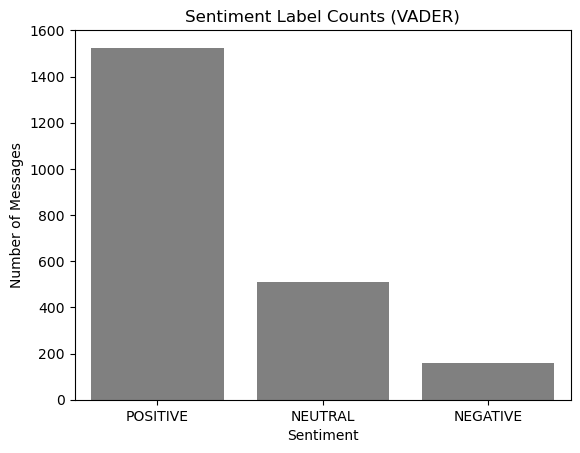

In [187]:
sns.barplot(x=sentiment_distribution.index, y=sentiment_distribution.values, order=['POSITIVE', 'NEUTRAL', 'NEGATIVE'], color=".5")
plt.title('Sentiment Label Counts (VADER)')
plt.xlabel('Sentiment')
plt.ylabel('Number of Messages')
plt.savefig('visualization/sentiment_label_counts.png')
plt.show()

## Analyze trends over time

In [188]:
df.head()

,Subject,body,date,from,sentiment_vader
0,EnronOptions Update!,EnronOptions Announcement We have updated the ...,5/10/2010,sally.beck@enron.com,POSITIVE
1,(No Subject),"Marc, Unfortunately, today is not going to wor...",7/29/2010,eric.bass@enron.com,POSITIVE
2,Phone Screen Interview - Shannon L. Burnham,"When: Wednesday, June 06, 2001 10:00 AM-11:00 ...",7/25/2011,sally.beck@enron.com,NEUTRAL
3,RE: My new work email,we were thinking papasitos (we can meet somewh...,3/25/2010,johnny.palmer@enron.com,NEUTRAL
4,Bet,Since you never gave me the $20 for the last t...,5/21/2011,lydia.delgado@enron.com,POSITIVE


We want to change the `date` feature from a string to date time.

In [189]:
df['date'] = pd.to_datetime(df['date'])
df['date']

0      2010-05-10
1      2010-07-29
2      2011-07-25
3      2010-03-25
4      2011-05-21
          ...    
2186   2011-06-17
2187   2011-01-20
2188   2011-01-02
2189   2011-03-11
2190   2010-10-30
Name: date, Length: 2191, dtype: datetime64[ns]

We want to plot the trend by month and year.

In [190]:
df['month'] = df['date'].dt.strftime('%m')
sentiment_trends = df.groupby('month')['sentiment_vader'].value_counts().unstack().fillna(0)
sentiment_trends

sentiment_vader,NEGATIVE,NEUTRAL,POSITIVE
month,,,
01,13,50,119
02,20,50,112
03,15,41,127
04,19,39,126
05,9,41,133
06,11,46,126
07,14,41,127
08,18,39,125
09,8,43,131


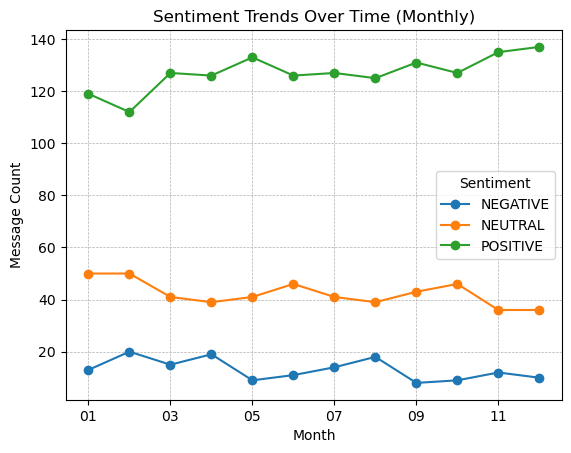

In [191]:
sentiment_trends.plot(kind='line', marker='o', linestyle='-')
plt.title('Sentiment Trends Over Time (Monthly)')
plt.xlabel('Month')
plt.ylabel('Message Count')
plt.legend(title='Sentiment')
plt.grid(linestyle='--', linewidth=0.5)
plt.savefig('visualization/sentiment_trends_monthly.png')
plt.show()

In [192]:
df['year'] = df['date'].dt.strftime('%Y')
sentiment_trends_year = df.groupby('year')['sentiment_vader'].value_counts().unstack().fillna(0)
sentiment_trends_year

sentiment_vader,NEGATIVE,NEUTRAL,POSITIVE
year,,,
2010,91,265,738
2011,67,243,787


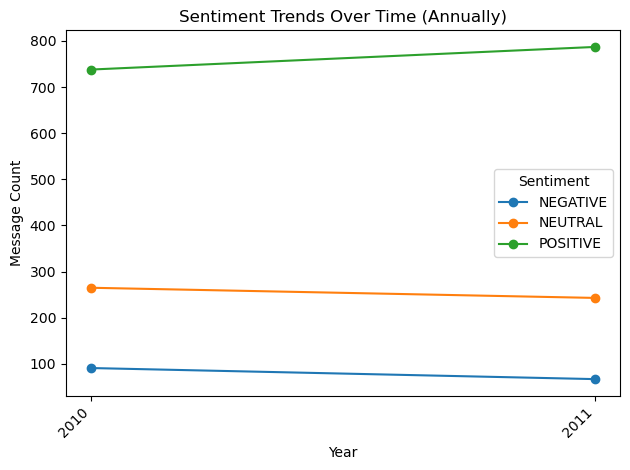

In [193]:
# Plot
for sentiment in sentiment_trends_year.columns:
    plt.plot(sentiment_trends_year.index, sentiment_trends_year[sentiment], marker='o', label=sentiment)

plt.title('Sentiment Trends Over Time (Annually)')
plt.xlabel('Year')
plt.ylabel('Message Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.legend(title='Sentiment')
plt.savefig('visualization/sentiment_trends_yearly.png')
plt.show()


## Explore additional patterns or anomalies that could provide insights into employee engagement.

In [194]:
df['message_length'] = df['body'].astype(str).apply(len)
df['message_length']

0       687
1       313
2       146
3       150
4       197
       ... 
2186    270
2187     71
2188    449
2189    643
2190     62
Name: message_length, Length: 2191, dtype: int64

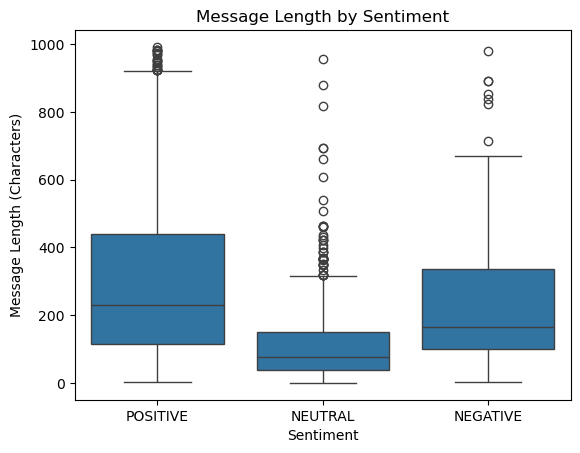

In [195]:
# Message Length Boxplot by Sentiment
sns.boxplot(data=df, x='sentiment_vader', y='message_length', order=['POSITIVE', 'NEUTRAL', 'NEGATIVE'])
plt.title('Message Length by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Message Length (Characters)')
plt.savefig('visualization/message_length_sentiment.png')
plt.show()

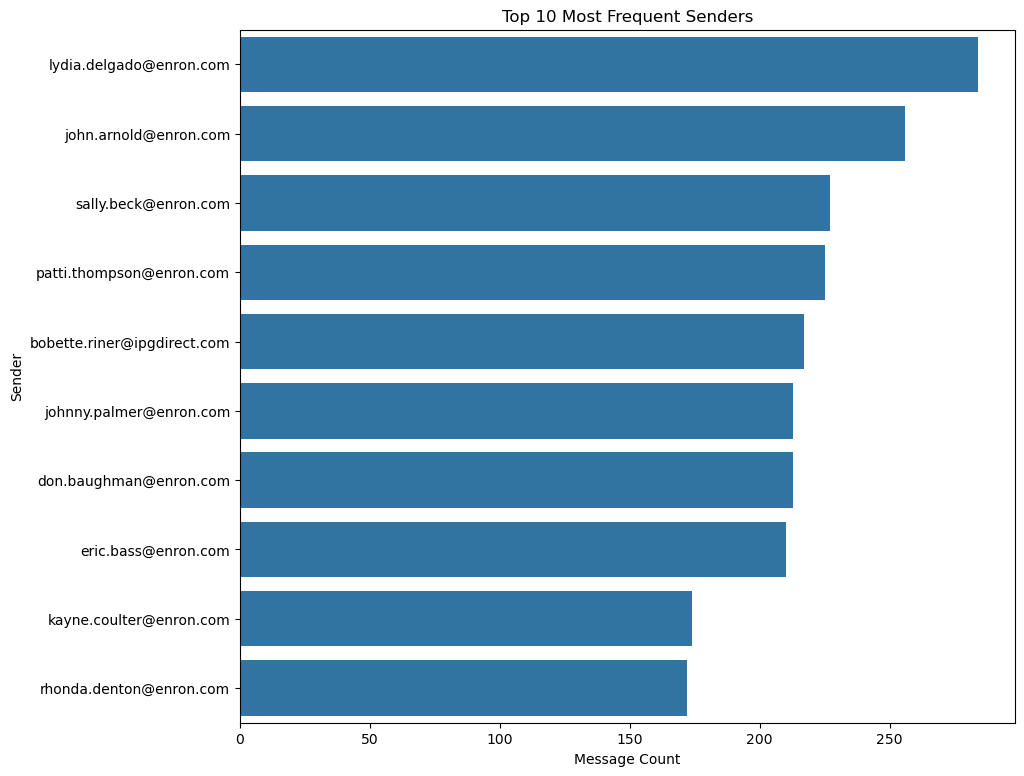

In [196]:
top_senders = df['from'].value_counts().head(10)

# Top 10 Senders
plt.figure(figsize=([10, 9]))
sns.barplot(y=top_senders.index, x=top_senders.values)
plt.title('Top 10 Most Frequent Senders')
plt.xlabel('Message Count')
plt.ylabel('Sender')
plt.savefig('visualization/top_10_senders.png')
plt.show()

In [197]:
top_senders = df['from'].value_counts().head(10)
top_senders.index

Index(['lydia.delgado@enron.com', 'john.arnold@enron.com',
       'sally.beck@enron.com', 'patti.thompson@enron.com',
       'bobette.riner@ipgdirect.com', 'johnny.palmer@enron.com',
       'don.baughman@enron.com', 'eric.bass@enron.com',
       'kayne.coulter@enron.com', 'rhonda.denton@enron.com'],
      dtype='object', name='from')

**Summary**:
- Message Length: Length message for neutral sentiment emails have many outliers (longer emails)
- Sentiment Dominance: The dataset is skewed toward Positive messages, with fewer Negative ones.
- Notable Spikes: A few months showed rises in Negative messages.
- Engagement Leaders: Some employees are frequent communicators, which may signal key stakeholders or potential burnout risks.

## Task 3: Employee Score Calculation

**Objective**: Compute a monthly sentiment score for each employee based on their messages.

Assigning a score to each message where:
- Positive Message: +1
- Negative Message: -1
- Neutral Message: 0 (no effect)

This score is stored in a new column called `sentiment_score`.


In [198]:
df.head()

,Subject,body,date,from,sentiment_vader,month,year,message_length
0,EnronOptions Update!,EnronOptions Announcement We have updated the ...,2010-05-10,sally.beck@enron.com,POSITIVE,05,2010,687
1,(No Subject),"Marc, Unfortunately, today is not going to wor...",2010-07-29,eric.bass@enron.com,POSITIVE,07,2010,313
2,Phone Screen Interview - Shannon L. Burnham,"When: Wednesday, June 06, 2001 10:00 AM-11:00 ...",2011-07-25,sally.beck@enron.com,NEUTRAL,07,2011,146
3,RE: My new work email,we were thinking papasitos (we can meet somewh...,2010-03-25,johnny.palmer@enron.com,NEUTRAL,03,2010,150
4,Bet,Since you never gave me the $20 for the last t...,2011-05-21,lydia.delgado@enron.com,POSITIVE,05,2011,197


In [199]:
# use a dictionary to map the sentiment labels based on its respective score.

sentiment_mapping = {
    'POSITIVE': 1,
    'NEGATIVE': -1,
    'NEUTRAL': 0
}

df['sentiment_score'] = df['sentiment_vader'].map(sentiment_mapping)
df.head()

,Subject,body,date,from,sentiment_vader,month,year,message_length,sentiment_score
0,EnronOptions Update!,EnronOptions Announcement We have updated the ...,2010-05-10,sally.beck@enron.com,POSITIVE,05,2010,687,1
1,(No Subject),"Marc, Unfortunately, today is not going to wor...",2010-07-29,eric.bass@enron.com,POSITIVE,07,2010,313,1
2,Phone Screen Interview - Shannon L. Burnham,"When: Wednesday, June 06, 2001 10:00 AM-11:00 ...",2011-07-25,sally.beck@enron.com,NEUTRAL,07,2011,146,0
3,RE: My new work email,we were thinking papasitos (we can meet somewh...,2010-03-25,johnny.palmer@enron.com,NEUTRAL,03,2010,150,0
4,Bet,Since you never gave me the $20 for the last t...,2011-05-21,lydia.delgado@enron.com,POSITIVE,05,2011,197,1


Aggregating the scores on a monthly basis for each employee

In [200]:
monthly_sentiment_scores = df.groupby(['from', 'month'])['sentiment_score'].sum().reset_index()
monthly_sentiment_scores

,from,month,sentiment_score
0,bobette.riner@ipgdirect.com,01,11
1,bobette.riner@ipgdirect.com,02,9
2,bobette.riner@ipgdirect.com,03,14
3,bobette.riner@ipgdirect.com,04,11
4,bobette.riner@ipgdirect.com,05,3
...,...,...,...
115,sally.beck@enron.com,08,16
116,sally.beck@enron.com,09,5
117,sally.beck@enron.com,10,8
118,sally.beck@enron.com,11,13


We sum the sentiment scores within each `(employee, month)` group. This ensures that each employee receives a monthly cumulative sentiment score, which resets at the beginning of each month.

## Task 4: Employee Ranking

**Objective**: It aims to generate ranked lists of employess based on their monthly sentiment scores.

### Top Three Positive Employees

In [201]:
# Create two new DataFrames: top 3 positive and top 3 negative per month
top_positive = (
    monthly_sentiment_scores
    .sort_values(by=['month', 'sentiment_score'], ascending=[True, False])
    .groupby('month')
    .head(3)
    .assign(type='Top Positive')
)

top_positive

,from,month,sentiment_score,type
24,eric.bass@enron.com,01,17,Top Positive
60,kayne.coulter@enron.com,01,14,Top Positive
72,lydia.delgado@enron.com,01,13,Top Positive
37,john.arnold@enron.com,02,26,Top Positive
49,johnny.palmer@enron.com,02,17,Top Positive
73,lydia.delgado@enron.com,02,15,Top Positive
86,patti.thompson@enron.com,03,17,Top Positive
110,sally.beck@enron.com,03,17,Top Positive
38,john.arnold@enron.com,03,16,Top Positive
75,lydia.delgado@enron.com,04,15,Top Positive


In [202]:
top_negative = (
    monthly_sentiment_scores
    .sort_values(by=['month', 'sentiment_score', 'from'], ascending=[True, True, True])
    .groupby('month')
    .head(3)
    .assign(type='Top Negative')
)

top_negative

,from,month,sentiment_score,type
12,don.baughman@enron.com,01,7,Top Negative
36,john.arnold@enron.com,01,7,Top Negative
108,sally.beck@enron.com,01,8,Top Negative
25,eric.bass@enron.com,02,1,Top Negative
61,kayne.coulter@enron.com,02,3,Top Negative
85,patti.thompson@enron.com,02,3,Top Negative
14,don.baughman@enron.com,03,3,Top Negative
50,johnny.palmer@enron.com,03,5,Top Negative
62,kayne.coulter@enron.com,03,7,Top Negative
111,sally.beck@enron.com,04,3,Top Negative


Sorting the `top_negative` based on the `sentiment_score` in a descending order and then in alphabetical order.

In [203]:
top_negative = top_negative.sort_values(by=['month', 'sentiment_score', 'from'], ascending=[True, False, True])
top_negative

,from,month,sentiment_score,type
108,sally.beck@enron.com,01,8,Top Negative
12,don.baughman@enron.com,01,7,Top Negative
36,john.arnold@enron.com,01,7,Top Negative
61,kayne.coulter@enron.com,02,3,Top Negative
85,patti.thompson@enron.com,02,3,Top Negative
25,eric.bass@enron.com,02,1,Top Negative
62,kayne.coulter@enron.com,03,7,Top Negative
50,johnny.palmer@enron.com,03,5,Top Negative
14,don.baughman@enron.com,03,3,Top Negative
27,eric.bass@enron.com,04,10,Top Negative


Concat the **Top Three Positive Employees** and **Top Three Negative Employees**.

In [204]:
employee_rankings = pd.concat([top_positive, top_negative]).sort_values(by=['month', 'type', 'sentiment_score', 'from'], ascending=[True, True, False, True])
employee_rankings.drop(columns=['type'], inplace=True)
employee_rankings

,from,month,sentiment_score
108,sally.beck@enron.com,01,8
12,don.baughman@enron.com,01,7
36,john.arnold@enron.com,01,7
24,eric.bass@enron.com,01,17
60,kayne.coulter@enron.com,01,14
...,...,...,...
11,bobette.riner@ipgdirect.com,12,7
59,johnny.palmer@enron.com,12,3
83,lydia.delgado@enron.com,12,21
47,john.arnold@enron.com,12,19


In [213]:
import matplotlib.pyplot as plt

def save_dataframe_as_image(df, filename, title=None):
    fig, ax = plt.subplots(figsize=(len(df.columns) * 2.5, len(df) * 0.5))
    ax.axis('off')
    table = ax.table(cellText=df.values,
                     colLabels=df.columns,
                     cellLoc='center',
                     loc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.5)
    if title:
        plt.title(title, fontsize=14, pad=20)
    plt.savefig(f'visualization/{filename}.png', bbox_inches='tight')
    plt.close()

In [214]:
save_dataframe_as_image(top_positive.head(10), "top_positive_employees", "Top Positive Employees")
save_dataframe_as_image(top_negative.head(10), "top_negative_employees", "Top Negative Employees")

#### How the Rankings Were Determined

1. **Input Source**:  
   This task builds on the output of Task 3, which contains each employee’s cumulative monthly sentiment score. Each message was previously scored as:
   - `+1` for Positive messages  
   - `0` for Neutral messages  
   - `–1` for Negative messages  

2. **Sorting & Selection**:
   - The dataset was first **grouped by `month`**.
   - Then, two rankings were computed for each month:
     - **Top Three Positive Employees**:
       - Sorted by `sentiment_score` in **descending** order (highest score first)
       - Then alphabetically by employee email in case of ties
     - **Top Three Negative Employees**:
       - Sorted by `sentiment_score` in **ascending** order (most negative first)
       - Then alphabetically by employee email

3. **Ranking Output**:
   - Each result includes:  
     - Employee email (`from`)  
     - Month (`month`)  
     - Total sentiment score for that month  
     - Type of ranking: `"Top Positive"` or `"Top Negative"`  
   - Only the top 3 employees from each category per month are shown

#### Result:
The output is presented as a combined table with clear labeling for both `Top Positive` and `Top Negative` rankings, sorted by month and category.

## Task 5: Flight Risk Identification

**Objective**: To identify employees who are at risk of leaving based on their monthly sentiment scores.

Filter only `NEGATIVE` sentiment scores.

In [205]:
negatives = df[df['sentiment_vader'] == 'NEGATIVE'][['from', 'date']].copy()
negatives

,from,date
9,kayne.coulter@enron.com,2010-02-06
13,don.baughman@enron.com,2010-09-24
17,sally.beck@enron.com,2010-07-07
26,don.baughman@enron.com,2010-11-06
42,sally.beck@enron.com,2011-08-15
...,...,...
2132,don.baughman@enron.com,2010-12-12
2163,bobette.riner@ipgdirect.com,2010-07-15
2169,john.arnold@enron.com,2010-06-18
2182,lydia.delgado@enron.com,2010-04-26


In [206]:
# Sort by employee and date
negatives = negatives.sort_values(by=['from', 'date'])
negatives

,from,date
1330,bobette.riner@ipgdirect.com,2010-02-21
598,bobette.riner@ipgdirect.com,2010-03-07
2163,bobette.riner@ipgdirect.com,2010-07-15
341,bobette.riner@ipgdirect.com,2010-08-06
120,bobette.riner@ipgdirect.com,2010-08-26
...,...,...
1978,sally.beck@enron.com,2011-08-06
42,sally.beck@enron.com,2011-08-15
148,sally.beck@enron.com,2011-08-17
195,sally.beck@enron.com,2011-08-22


In [208]:
# Apply rolling difference within each employee group
flight_risk_employees = set()

# Group by employee
for sender, group in negatives.groupby('from'):
    group = group.reset_index(drop=True)
    dates = group['date']
    
    # Check rolling windows
    for i in range(len(dates)):
        count = 1
        for j in range(i+1, len(dates)):
            if (dates[j] - dates[i]).days <= 30:
                count += 1
            else:
                break
        if count >= 4:
            flight_risk_employees.add(sender)
            break

# Final output
flight_risk_df = pd.DataFrame({'at_risk_employee': list(flight_risk_employees)})
flight_risk_df

,at_risk_employee
0,johnny.palmer@enron.com
1,john.arnold@enron.com
2,bobette.riner@ipgdirect.com
3,kayne.coulter@enron.com
4,sally.beck@enron.com
5,don.baughman@enron.com


In [ ]:
save_dataframe_as_image(flight_risk_df.head(10), "at_risk_employee", "Flight Risk Employees")


## Task 6: Predictive Modeling

**Objective**: Develop a linear regression model to analyze sentiment trends and predict future sentiment scores

In [209]:
df

,Subject,body,date,from,sentiment_vader,month,year,message_length,sentiment_score
0,EnronOptions Update!,EnronOptions Announcement We have updated the ...,2010-05-10,sally.beck@enron.com,POSITIVE,05,2010,687,1
1,(No Subject),"Marc, Unfortunately, today is not going to wor...",2010-07-29,eric.bass@enron.com,POSITIVE,07,2010,313,1
2,Phone Screen Interview - Shannon L. Burnham,"When: Wednesday, June 06, 2001 10:00 AM-11:00 ...",2011-07-25,sally.beck@enron.com,NEUTRAL,07,2011,146,0
3,RE: My new work email,we were thinking papasitos (we can meet somewh...,2010-03-25,johnny.palmer@enron.com,NEUTRAL,03,2010,150,0
4,Bet,Since you never gave me the $20 for the last t...,2011-05-21,lydia.delgado@enron.com,POSITIVE,05,2011,197,1
...,...,...,...,...,...,...,...,...,...
2186,Re: Resume,Thanks for the resume. She has had some good ...,2011-06-17,johnny.palmer@enron.com,POSITIVE,06,2011,270,1
2187,"Final Schedule - Wednesday, May 2, 2001 - Jesu...",Attached please find the following documents: ...,2011-01-20,johnny.palmer@enron.com,POSITIVE,01,2011,71,1
2188,(No Subject),Good to finally hear from. Judging from your ...,2011-01-02,don.baughman@enron.com,POSITIVE,01,2011,449,1
2189,League is Set,It looks like we have our 12 teams. We will p...,2011-03-11,rhonda.denton@enron.com,POSITIVE,03,2011,643,1


In [210]:
# Select features and target
features = df[['month', 'year', 'message_length']]
target = df['sentiment_score']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.3, random_state=42)

# Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)


In [211]:
# Collect model coefficients for interpretation
coefficients = pd.DataFrame({
    'Feature': features.columns,
    'Coefficient': model.coef_
})

# Prepare results
results = pd.DataFrame({
    'Mean Squared Error': [mse],
    'R^2 Score': [r2]
})

coefficients

,Feature,Coefficient
0,month,0.010553
1,year,0.034086
2,message_length,0.000565


In [212]:
results

,Mean Squared Error,R^2 Score
0,0.373989,0.063099


### Summary & Insights

- The model finds **only weak linear relationships** between the selected features and sentiment scores.
- **Message length** was not a strong predictor.
- **Time-based variables** (month, year) show very limited impact, suggesting sentiment trends are not strongly seasonal or yearly in nature.
- The low **R² Score** indicates that **other features**  may be more influential and worth including in future models.
- We used **MSE and R^2** for the evaluation metrics is because MSE tells how far off the monthly sentiment predictions are and R^2 tells Whether the model explains any meaningful variation in sentiment trends.
- Recommendations for improving the prediction: 
    - Engineer more meaningful features
    - Use larger dataset
    - Try non-linear models.


---


## Citation

Hutto, C.J. & Gilbert, E.E. (2014). VADER: A Parsimonious Rule-based Model for
Sentiment Analysis of Social Media Text. Eighth International Conference on
Weblogs and Social Media (ICWSM-14). Ann Arbor, MI, June 2014.
